In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Matemáticas para aprendizaje automático

## Álgebra lineal

### Descomposiciones matriciales

**David Ramírez**

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='./figures/UC3M.svg' width=300 />



### Contenidos

- Descomposición en autovalores y autovectores
- Descomposición en valores singulares
- Otras descomposiciones (LU, Cholesky y QR)


## Descomposición en autovalores y autovectores

#### ¿Qué es un autovector y un autovalor?

Dado un vector $\mathbf{x} \in \mathbb{R}^{n}$ y una matriz $\mathbf{A} \in \mathbb{R}^{n \times n}$, la operación

\begin{equation}
{\mathbf y} = {\mathbf A} {\mathbf x}
\end{equation}

es una transformación lineal (genérica) de ${\mathbf x}$


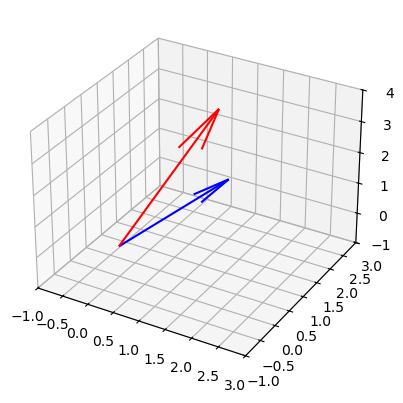

In [2]:
# Matriz y vector de ejemplo
A = np.array([[.1,.2,.3],[.4,.5,.6],[.7,.8,.9]])
x = np.array([1, 2, 1])

# Transformación lineal
y = A @ x

# Pintamos los vectores
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.quiver(0, 0, 0, x[0], x[1], x[2], color='blue')
ax.quiver(0, 0, 0, y[0], y[1], y[2], color='red')
ax.set_xlim([-1,3])
ax.set_ylim([-1,3])
ax.set_zlim([-1,4])
plt.show()

Sin embargo, para algunos vectores, la transformación lineal es un simple escalado del vector, es decir,

\begin{equation}
{\mathbf y} = {\mathbf A} {\mathbf x} = \lambda {\mathbf x}
\end{equation}

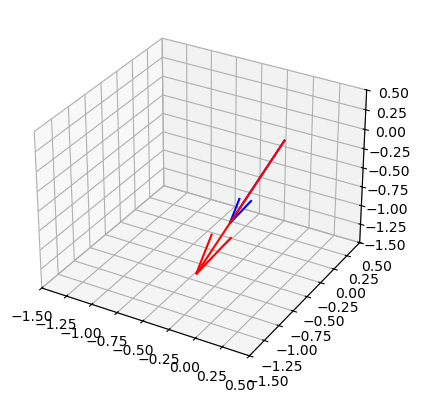

In [3]:
# Nuevo vector de ejemplo
x_2 = np.array([-0.23197069, -0.52532209, -0.8186735])

# Transformación lineal
y_2 = A @ x_2

# Pintamos los vectores
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.quiver(0, 0, 0, x_2[0], x_2[1], x_2[2], color='blue')
ax.quiver(0, 0, 0, y_2[0], y_2[1], y_2[2], color='red')
ax.set_xlim([-1.5,0.5])
ax.set_ylim([-1.5,0.5])
ax.set_zlim([-1.5,0.5])
plt.show()

Es obvio que esto pasa (trivialmente) para ${\mathbf x} = {\mathbf y}$. Para los casos no triviales, ${\mathbf x} \neq {\mathbf y}$, el vector ${\mathbf x}$ se conoce como **autovector** y el escalar $\lambda$ es el correspondiente **autovalor**. En general, para una matriz ${\mathbf A} \in \mathbb{R}^{n \times n}$ habrá $n$ pares de autovector-autovalor.

#### Polinomio característico

El polinomio característico de la matriz ${\mathbf A} \in \mathbb{R}^{n \times n}$ se define como

\begin{equation}
p_{{\mathbf A}}(z) = \operatorname{det}(z {\mathbf I} - {\mathbf A} )
\end{equation}

que tendrá order $n$. A partir del polinómio característico se puede obtener los autovalores. Concretamente, $\lambda$ será un autovalor de ${\mathbf A}$ si

\begin{equation}
p_{{\mathbf A}}(\lambda) = 0
\end{equation}

Dado que el orden de $p_{{\mathbf A}}(z)$ es $n$, dicho polinomio tendrá $n$ raíces y, por lo tanto, las $n$ raíces serán los $n$ autovalores de ${\mathbf A}$:

\begin{equation}
p_{{\mathbf A}}(z) = (z - \lambda_1)(z - \lambda_2) \cdots (z - \lambda_n)
\end{equation}

Aunque alguno de estos autovalores podría estar repetido (la multiplicidad de la raíz es mayor que $1$).

Finalmente, para obtener el correspondiente autovector habrá que resolver el sistema de ecuaciones

\begin{equation}
(\lambda {\mathbf I} - {\mathbf A}) {\mathbf x} = {\mathbf y}
\end{equation}

Del sistema de ecuaciones anterior, se puede ver que si ${\mathbf x}$ es una solución $c {\mathbf x}$ también lo será. Esto genera un grado de libertad para parametrizar ${\mathbf x}$ y lo habitual es escoger que $\| {\mathbf x} \|_2 = 1$. Si, además, la multiplicidad del autovalor es mayor que $1$, habrá varios ${\mathbf x}$ linealmente independientes que cumplan $(\lambda {\mathbf I} - {\mathbf A}) {\mathbf x} = {\mathbf y}$, y será necesario imponer restricciones adicionales sobre la relación entre los diferentes autovectores

#### Descomposición en autovalores y autovectores

Juntando la definición de los $n$ pares de autovalores y autovectores, es decir,

\begin{equation}
{\mathbf A} {\mathbf x}_i = \lambda_i {\mathbf x}_i, \quad i = 1, \ldots, n
\end{equation}

en una única ecuación, se obtiene

\begin{equation}
\DeclareMathOperator{\tr}{tr}
\DeclareMathOperator{\det}{det}
\DeclareMathOperator{\rank}{rank}
\left[
\begin{array}{ccccc}
& &  &  &  \\
& &  &  &  \\
& & {\mathbf A} &  &  \\
& &  &  &  \\
& &  &  &  
\end{array}
\right]
\underbrace{\left[
\begin{array}{c|c|c|c}
 &  &  &  \\
&  &  &  \\
{\mathbf x}_1 & {\mathbf x}_2 & \cdots & {\mathbf x}_n \\
&  &  &  \\
&  &  &  
\end{array}
\right]}_{{\mathbf X}}
=
\underbrace{\left[
\begin{array}{c|c|c|c}
 &  &  &  \\
&  &  &  \\
{\mathbf x}_1 & {\mathbf x}_2 & \cdots & {\mathbf x}_n \\
&  &  &  \\
&  &  &  
\end{array}
\right]}_{{\mathbf X}}
\underbrace{\left[
\begin{array}{cccc}
\lambda_1 & 0 & \cdots & 0 \\
0 & \lambda_2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & \lambda_n
\end{array}
\right]}_{{\boldsymbol \Lambda}}
\end{equation}

Por lo tanto, de la relación ${\mathbf A} {\mathbf X} = {\mathbf X} {\boldsymbol \Lambda}$ se puede derivar la descomposición en autovalores y autovectores (*eigenvalue decomposition*, EVD)

\begin{equation}
{\mathbf A} = {\mathbf X} {\boldsymbol \Lambda} {\mathbf X}^{-1}
\end{equation}

suponiendo que ${\mathbf X}$ es no singular

#### Traza, determinante y rango de una matriz

La EVD nos permite calcular la traza, el determinante, y el rango (ya estudiaremos su significado en la sección de "Espacios vectoriales") en función de los autovalores

1. $\operatorname{tr}({\mathbf A}) = \sum_{i = 1}^n \lambda_i$
2. $\operatorname{det}({\mathbf A}) = \prod_{i = 1}^n \lambda_i$
3. El rango de una matriz viene dado por el número de autovalores no nulos

In [4]:
# EVD de A
Lambda, X = np.linalg.eig(A)

# Traza, determinante y rango de A
print(np.trace(A))
print(np.sum(Lambda))

print(np.linalg.det(A))
print(np.prod(Lambda))

print(np.linalg.matrix_rank(A))
print(np.sum(np.abs(Lambda)>1e-6))

1.5
1.4999999999999996
4.448822262962232e-18
4.1924964558846626e-18
2
2


<img src='./figures/lapiz.png' width=40 /> Problema 1

#### Matrices normales y su EVD

Una matriz normal es aquella que conmuta con su traspuesta, es decir, ${\mathbf A} {\mathbf A}^T = {\mathbf A}^T {\mathbf A}$. Un ejemplo trivial, aunque muy útil, de matriz normal es una matriz simétrica

Para una matriz ${\mathbf A}$ normal, su EVD se simplifica a

\begin{equation}
{\mathbf A} = {\mathbf U} {\boldsymbol \Lambda} {\mathbf U}^T
\end{equation}

donde ${\mathbf U}$ es una matriz **ortogonal**. Es decir, en este caso hemos sustituido ${\mathbf U}^{-1}$ por ${\mathbf U}^T$. La EVD también se puede expresar a través de las columnas de ${\mathbf U}$:

\begin{equation}
{\mathbf A} = \sum_{i = 1}^{n} \lambda_i {\mathbf u}_i {\mathbf u}_i^T
\end{equation}

In [5]:
# "Normalizamos" A
B = A @ A.T
Lambda_B, U = np.linalg.eig(B)

# U es ortogonal
print(U.T @ U)
print(U @ U.T)

[[ 1.00000000e+00 -2.45342261e-16  2.39242500e-16]
 [-2.45342261e-16  1.00000000e+00 -8.16317565e-15]
 [ 2.39242500e-16 -8.16317565e-15  1.00000000e+00]]
[[ 1.00000000e+00 -5.24346636e-15  1.38446233e-15]
 [-5.24346636e-15  1.00000000e+00  3.51643859e-15]
 [ 1.38446233e-15  3.51643859e-15  1.00000000e+00]]


#### Funciones matriciales y la EVD

Supongamos que queremos calcular una funcion de una matriz, es decir $f({\mathbf A})$. Nótese que esta operación no es aplicar la función a cada uno de los elementos $a_{ij}$. Para esto la EVD juega un papel clave. Dada la EVD

\begin{equation}
{\mathbf A} = {\mathbf X} {\boldsymbol \Lambda} {\mathbf X}^{-1}
\end{equation}

podemos calcular $f({\mathbf A})$ como

\begin{equation}
f({\mathbf A}) = {\mathbf X} f({\boldsymbol \Lambda}) {\mathbf X}^{-1}
\end{equation}

donde

\begin{equation}
f({\boldsymbol \Lambda}) = 
\begin{bmatrix}
f(\lambda_1) & 0 & \cdots & 0 \\
0 & f(\lambda_2) & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & f(\lambda_n)
\end{bmatrix}
\end{equation}

Es decir, se ha transformado una función matricial en una EVD y la aplicación de la función a cada uno de los autovalores.

El siguiente código de Python calcula la matriz raíz cuadrada con esta idea, que es uno de los casos más típicos de funciones matriciales (aunque hay otras formas de hacerlo)

In [6]:
# Creamos una matriz con autovalores positivos (para no acabar con número complejos)
Lambda = [1,1.5,2]
C = X @ np.diag(Lambda) @ np.linalg.inv(X)

# Matriz raíz cuadrada
C_raiz = X @ np.diag(np.sqrt(Lambda)) @ np.linalg.inv(X)
C_raiz_bis = sp.linalg.sqrtm(C)

# C_raiz * C_raiz = C
print(C)
print(C_raiz @ C_raiz)
print(C_raiz_bis @ C_raiz_bis)

[[ 1.52731795 -0.23549353  0.00169499]
 [-0.29351941  1.67746764 -0.3515453 ]
 [-0.11435678 -0.40957118  1.29521441]]
[[ 1.52731795 -0.23549353  0.00169499]
 [-0.29351941  1.67746764 -0.3515453 ]
 [-0.11435678 -0.40957118  1.29521441]]
[[ 1.52731795 -0.23549353  0.00169499]
 [-0.29351941  1.67746764 -0.3515453 ]
 [-0.11435678 -0.40957118  1.29521441]]


## Descomposición en valores singulares

La descomposición en valores singulares (*singular value decomposition*, SVD) se puede interpretar como una generalización de la EVD para matrices rectangulares.

#### SVD reducida

En el caso de autovalores y autovectores, si ${\mathbf x}_i$ es un autovector de ${\mathbf A}$ se obtiene

\begin{equation}
{\mathbf A} {\mathbf x}_i = \lambda_i {\mathbf x}_i, \quad i = 1, \ldots, n
\end{equation}

Esto es, la transformación lineal ${\mathbf A} {\mathbf x}_i$ resulta en un escalado de ${\mathbf x}_i$. Supongamos ahora que ${\mathbf A}$ es una matriz rectangular de tamaño $m \times n$, con $m \geq n$. Para esta matriz se definen los vectores singulares por la izquierda ${\mathbf u}_i$ y por la derecha ${\mathbf v}_i$ como aquellos que cumplen

\begin{equation}
{\mathbf A} {\mathbf v}_i = \sigma_i {\mathbf u}_i, \quad i = 1, \ldots, n
\end{equation}

donde $\sigma_i \ (\sigma_i \geq 0)$ es el valor singular correspondiente. Además, estos vectores singulares cumplen ${\mathbf v}_i^T {\mathbf v}_j = 0, {\mathbf u}_i^T {\mathbf u}_j = 0, \ i \neq j$ y ${\mathbf v}_i^T {\mathbf v}_i = {\mathbf u}_i^T {\mathbf u}_i = 1$. Al igual que antes, este conjunto de $n$ ecuaciones se puede escribir en una única ecuación como

\begin{equation}
\left[
\begin{array}{ccccc}
& &  &  &  \\
& &  &  &  \\
& &  &  &  \\
& & {\mathbf A} &  &  \\
& &  &  &  \\
& &  &  &  \\
& &  &  &  
\end{array}
\right]
\underbrace{\left[
\begin{array}{c|c|c|c}
 &  &  &  \\
&  &  &  \\
{\mathbf v}_1 & {\mathbf v}_2 & \cdots & {\mathbf v}_n \\
&  &  &  \\
&  &  &  
\end{array}
\right]}_{{\mathbf V}}
=
\underbrace{\left[
\begin{array}{c|c|c|c}
&  &  &  \\
 &  &  &  \\
&  &  &  \\
{\mathbf u}_1 & {\mathbf u}_2 & \cdots & {\mathbf u}_n \\
&  &  &  \\
&  &  &  \\
&  &  &  \\
\end{array}
\right]}_{\tilde{{\mathbf U}}}
\underbrace{\left[
\begin{array}{cccc}
\sigma_1 & 0 & \cdots & 0 \\
0 & \sigma_2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & \sigma_n
\end{array}
\right]}_{\tilde{{\boldsymbol \Sigma}}}
\end{equation}

Debido a las condiciones de los vectores singulares por la derecha, la matriz ${\mathbf V}$ es ortogonal, lo que nos permite reescribir ${\mathbf A} {\mathbf V} = \tilde{{\mathbf U}} \tilde{{\boldsymbol \Sigma}}$ como

\begin{equation}
{\mathbf A} = \tilde{{\mathbf U}} \tilde{{\boldsymbol \Sigma}} {\mathbf V}^T
\end{equation}

que es la SVD reducida de ${\mathbf A}$, con $\tilde{{\mathbf U}} \in \mathbb{R}^{m \times n}, \tilde{{\boldsymbol \Sigma}} \in \mathbb{R}^{n \times n}$ y ${\mathbf V} \in \mathbb{R}^{n \times n}$. La siguiente figura lo muestra gráficamente

<img 
    style="display: block; 
           margin-left: auto;
           margin-right: auto;
           width: 40%;"
    src='./figures/SVD_reduced.svg'/>
</img>

Como $\tilde{{\mathbf U}}$ no es cuadrada no es una matriz ortogonal. Sin embargo, sus columnas si son ortogonales y cumplen:

\begin{equation}
\tilde{{\mathbf U}}^T \tilde{{\mathbf U}} = {\mathbf I} \hspace{2cm} \tilde{{\mathbf U}} \tilde{{\mathbf U}}^T \neq {\mathbf I}
\end{equation}

In [7]:
# Matrices de ejemplo
A = np.array([[1,2,3],[4,5,6],[7,8,9],[10,11,12]])

# SVD reducida
U_tilde,S_tilde,V = np.linalg.svd(A,full_matrices=False)

print(U_tilde @ np.diag(S_tilde) @ V) # Nótese que linalg.svd devuelve V.T en lugar de V
print(U_tilde)
print(S_tilde)
print(V)

# U no es ortogonal
print(U_tilde.T @ U_tilde)
print(U_tilde @ U_tilde.T)

# V es ortogonal
print(V.T @ V)
print(V @ V.T)

[[ 1.  2.  3.]
 [ 4.  5.  6.]
 [ 7.  8.  9.]
 [10. 11. 12.]]
[[-0.14087668 -0.82471435  0.54704904]
 [-0.34394629 -0.42626394 -0.70915928]
 [-0.54701591 -0.02781353 -0.22282857]
 [-0.75008553  0.37063688  0.38493881]]
[2.54624074e+01 1.29066168e+00 1.80972823e-15]
[[-0.50453315 -0.5745157  -0.64449826]
 [ 0.76077568  0.05714052 -0.64649464]
 [-0.40824829  0.81649658 -0.40824829]]
[[ 1.00000000e+00  1.91772589e-16 -2.15328113e-16]
 [ 1.91772589e-16  1.00000000e+00 -2.41659718e-16]
 [-2.15328113e-16 -2.41659718e-16  1.00000000e+00]]
[[ 0.99926266  0.01205509 -0.02189816  0.01058041]
 [ 0.01205509  0.80290688  0.35802095 -0.17298293]
 [-0.02189816  0.35802095  0.34965257  0.31422463]
 [ 0.01058041 -0.17298293  0.31422463  0.84817789]]
[[ 1.00000000e+00 -1.17859403e-17 -2.28916495e-17]
 [-1.17859403e-17  1.00000000e+00 -2.25135648e-16]
 [-2.28916495e-17 -2.25135648e-16  1.00000000e+00]]
[[ 1.00000000e+00 -3.58997903e-17  2.87055419e-16]
 [-3.58997903e-17  1.00000000e+00  1.07097661e-16]
 [

#### SVD completa

Para "arreglar" la falta de ortogonalidad de $\tilde{{\mathbf U}}$, se puede calcular la SVD completa de ${\mathbf A}$. Concretamente, la matriz $\tilde{{\mathbf U}}$ no es ortogonal por no ser cuadrada. ¿Qué necesitamos para completar $\tilde{{\mathbf U}}$, que sea una matriz ortogonal, pero que siga descomponiendo ${\mathbf A}$? Gráficamente se puede ver en la siguiente figura

<img 
    style="display: block; 
           margin-left: auto;
           margin-right: auto;
           width: 45%;"
    src='./figures/SVD_complete.svg'/>
</img>

Algebraicamente se demuestra que da igual las columnas que añadamos a la derecha de $\tilde{{\mathbf U}}$ si añadimos los ceros correspondientes como filas por debajo de $\tilde{{\boldsymbol \Sigma}}$. Entonces, para obtener una matriz de vectores singulares por la izquierda ortogonal ${\mathbf U}$, necesitaremos

\begin{equation}
{\mathbf U} = \begin{bmatrix} \tilde{{\mathbf U}} & \tilde{{\mathbf U}}^{\perp} \end{bmatrix}
\end{equation}

con $\tilde{{\mathbf U}}^T \tilde{{\mathbf U}}^{\perp} = {\boldsymbol 0}$ y $\left(\tilde{{\mathbf U}}^{\perp} \right)^T \tilde{{\mathbf U}}^{\perp} = {\mathbf I}$. Asimismo, habrá que completar la matriz de valores singulares como indica la imagen, es decir

\begin{equation}
{\boldsymbol \Sigma} = \begin{bmatrix} \tilde{{\boldsymbol \Sigma}} \\ {\boldsymbol 0} \end{bmatrix}
\end{equation}

Con todo esto, la SVD completa de ${\mathbf A}$ es

\begin{equation}
{\mathbf A} = {\mathbf U} {\boldsymbol \Sigma} {\mathbf V}^T
\end{equation}

con ${\mathbf U} \in \mathbb{R}^{m \times m}, {\boldsymbol \Sigma} \in \mathbb{R}^{m \times n}$ y ${\mathbf V} \in \mathbb{R}^{n \times n}$. Además, ahora ${\mathbf U}$ es ortogonal, ${\mathbf U}^T {\mathbf U} = {\mathbf U} {\mathbf U}^T = {\mathbf I}$

In [8]:
# Matrices de ejemplo
A = np.array([[1,2,3],[4,5,6],[7,8,9],[10,11,12]])

# SVD completa
U,S,V = np.linalg.svd(A,full_matrices=True)

print(U)
print(S)  # Nótese que en S no se ve el efecto
print(V)

# U es ortogonal
print(U.T @ U)
print(U @ U.T)

# V es ortogonal
print(V.T @ V)
print(V @ V.T)

[[-0.14087668 -0.82471435  0.54704904 -0.02715407]
 [-0.34394629 -0.42626394 -0.70915928  0.4439517 ]
 [-0.54701591 -0.02781353 -0.22282857 -0.80644121]
 [-0.75008553  0.37063688  0.38493881  0.38964357]]
[2.54624074e+01 1.29066168e+00 1.80972823e-15]
[[-0.50453315 -0.5745157  -0.64449826]
 [ 0.76077568  0.05714052 -0.64649464]
 [-0.40824829  0.81649658 -0.40824829]]
[[ 1.00000000e+00  1.91772589e-16 -2.15328113e-16 -7.73777063e-17]
 [ 1.91772589e-16  1.00000000e+00 -2.41659718e-16  1.77330866e-17]
 [-2.15328113e-16 -2.41659718e-16  1.00000000e+00  6.00809515e-17]
 [-7.73777063e-17  1.77330866e-17  6.00809515e-17  1.00000000e+00]]
[[1.00000000e+00 2.12096637e-17 1.17395228e-16 2.89167607e-16]
 [2.12096637e-17 1.00000000e+00 6.11662705e-17 1.69321311e-16]
 [1.17395228e-16 6.11662705e-17 1.00000000e+00 1.57853746e-16]
 [2.89167607e-16 1.69321311e-16 1.57853746e-16 1.00000000e+00]]
[[ 1.00000000e+00 -1.17859403e-17 -2.28916495e-17]
 [-1.17859403e-17  1.00000000e+00 -2.25135648e-16]
 [-2.2

##### ¿Qué pasaría en el caso de $m < n$?

<img src='./figures/lapiz.png' width=40 /> Complete el siguiente código y extraiga conclusiones relativas al tamaño de las matrices

In [9]:
# Matrices de ejemplo
A = np.array([[1,2,3],[4,5,6],[7,8,9],[10,11,12]]).T
print(A)

# ...

[[ 1  4  7 10]
 [ 2  5  8 11]
 [ 3  6  9 12]]


<img src='./figures/lapiz.png' width=40 /> Problema 2

#### La pseudo-inversa y la SVD

En esta sección vamos a ver cómo se calcula la pseudo-inversa usando la SVD. Comencemos por considerar la pseudo-inversa de ${\boldsymbol \Sigma}$, que es

\begin{equation}
{\boldsymbol \Sigma}^{\#} = \begin{bmatrix} \tilde{{\boldsymbol \Sigma}}^{-1} & {\boldsymbol 0}^T \end{bmatrix}
\end{equation}

donde $\tilde{{\boldsymbol \Sigma}}^{-1}$ es una matriz diagonal con los inversos de los elementos de la diagonal de $\tilde{{\boldsymbol \Sigma}}$ o ceros si los elementos correspondientes de $\tilde{{\boldsymbol \Sigma}}$ eran cero, y ${\boldsymbol 0}^T$ es una matriz de ceros de dimensiones $n \times (m-n)$ (ya que ${\boldsymbol 0}$ en la definición de ${\boldsymbol \Sigma}$ es una matriz de ceros de dimensiones $(m-n) \times n$. Es fácil ver que ${\boldsymbol \Sigma}^{\#}$ cumple todas las condiciones de la matriz pseudo-inversa.

Una vez que hemos calculado la pseudo-inversa de una matriz diagonal rectangular, es fácil calcular la pseudo-inversa de ${\mathbf A} = {\mathbf U} {\boldsymbol \Sigma} {\mathbf V}^T$ como

\begin{equation}
{\mathbf A}^{\#} = {\mathbf V} {\boldsymbol \Sigma}^{\#} {\mathbf U}^T
\end{equation}

<img src='./figures/lapiz.png' width=40 /> Demuestre que ${\mathbf A}^{\#}$ cumple las condiciones para ser una pseudo-inversa (analíticamente o con código)

In [10]:
# Matrices de ejemplo
A = np.array([[1,3,7],[4,2,9],[5,8,6], [12,10,13]])

# Pseudo-inversa de A usando Numpy
A_pinv = np.linalg.pinv(A)
print(A_pinv)

# Pseudo-inversa de A usando la SVD
U,S,V = np.linalg.svd(A,full_matrices=True)

S_pinv = np.zeros((3, 4))
S_pinv[:3, :3] = np.diag(1./S)
A_pinv2 = V.T @ S_pinv @ U.T
print(A_pinv2)

[[-0.18424785  0.01496294 -0.10804671  0.13871914]
 [ 0.07248973 -0.11441903  0.18009918 -0.04294246]
 [ 0.09988802  0.09075348 -0.02489202 -0.02820349]]
[[-0.18424785  0.01496294 -0.10804671  0.13871914]
 [ 0.07248973 -0.11441903  0.18009918 -0.04294246]
 [ 0.09988802  0.09075348 -0.02489202 -0.02820349]]


<img src='./figures/lapiz.png' width=40 /> Problema 3

## Descomposición LU

La descomposición LU (*lower-upper*) es otra descomposición matricial con importantes aplicaciones, siendo una de ellas la resolución de sistemas de ecuaciones. Concretamente, la descomposición LU factoriza una matriz regular como

\begin{equation}
{\mathbf A} = {\mathbf L} {\mathbf U}
\end{equation}

donde ${\mathbf L}$ es una matriz triangular inferior y ${\mathbf U}$ es una matriz triangular superior. Esquemáticamente es

<img 
    style="display: block; 
           margin-left: auto;
           margin-right: auto;
           width: 40%;"
    src='./figures/LU.svg'/>
</img>

Además, es habitual que los elementos de la diagonal de ${\mathbf L}$ o ${\mathbf U}$ sean $1$

*Nota:* En algunos casos, para evitar problemas es necesario aplicar una permutación a las filas (o columnas) para poder calcular la factorización LU, quedando en este caso

\begin{equation}
{\mathbf P} {\mathbf A} = {\mathbf L} {\mathbf U} \qquad \Rightarrow \qquad {\mathbf A} = {\mathbf P} {\mathbf L} {\mathbf U}
\end{equation}

#### Descomposición LDU (u otras variantes)

A veces puede resultar más conveniente que los valores de la diagonal de ${\mathbf L}$ y ${\mathbf U}$ sean $1$. En este caso, dichos valores se absorben en una matriz diagonal, por lo que quedaría

\begin{equation}
{\mathbf A} = {\mathbf L} {\mathbf D} {\mathbf U}
\end{equation}

También existiría la descomposición UL o la UDL. Además es posible generalizar estas descomposiciones a matrices rectangulares.

In [11]:
# Matrices de ejemplo
A = np.array([[5,8,6],[4,2,9],[1,3,7]])
B = np.array([[1,3,7],[4,2,9],[5,8,6]])

# Scipy usa la alternativa 2: A = P*L*U
_, L, U = sp.linalg.lu(A)

print(L)
print(U)
print(L @ U)

# Qué pasa con la matriz B
P, L, U = sp.linalg.lu(B)

print(P)
print(L)
print(U)
print(L @ U)
print(P @ L @ U)

[[ 1.          0.          0.        ]
 [ 0.8         1.          0.        ]
 [ 0.2        -0.31818182  1.        ]]
[[ 5.          8.          6.        ]
 [ 0.         -4.4         4.2       ]
 [ 0.          0.          7.13636364]]
[[5. 8. 6.]
 [4. 2. 9.]
 [1. 3. 7.]]
[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]
[[ 1.          0.          0.        ]
 [ 0.8         1.          0.        ]
 [ 0.2        -0.31818182  1.        ]]
[[ 5.          8.          6.        ]
 [ 0.         -4.4         4.2       ]
 [ 0.          0.          7.13636364]]
[[5. 8. 6.]
 [4. 2. 9.]
 [1. 3. 7.]]
[[1. 3. 7.]
 [4. 2. 9.]
 [5. 8. 6.]]


<img src='./figures/lapiz.png' width=40 /> Repita el ejemplo anterior para una matriz rectangular y analice la estructura de ${\mathbf L}$ y ${\mathbf U}$. Considere los casos de más filas que columnas y viceversa

In [12]:
# Matrices de ejemplo
A = np.array([[1,2,3],[4,5,6],[7,8,9],[10,11,12]])
B = A.T

# ...

#### Descomposición LU y sistemas de ecuaciones

Supongamos un sistema de ecuaciones con el mismo número de incognitas que ecuaciones. En este caso, dicho sistema se puede representar mediante la ecuación

\begin{equation}
{\mathbf A} {\mathbf x} = {\mathbf b}
\end{equation}

donde ${\mathbf A}$ es una matriz cuadrada. Una manera sencilla de resolver el sistema es con la matriz inversa, es decir, ${\mathbf x} = {\mathbf A}^{-1} {\mathbf b}$, pero esta opción tiene una estabilidad numérica pobre. Una alternativa más estable numéricamente es mediante la descomposición ${\mathbf A} = {\mathbf L} {\mathbf U}$ (suponemos que no es necesaria la permutación), que resulta en

\begin{equation}
{\mathbf L} {\mathbf U} {\mathbf x} = {\mathbf b} \quad \Rightarrow \quad {\mathbf L} {\mathbf y} = {\mathbf b}
\end{equation}

donde se ha definido ${\mathbf U} {\mathbf x} = {\mathbf y}$. La ecuación ${\mathbf L} {\mathbf y} = {\mathbf b}$ se puede escribir

\begin{align}
l_{11} y_1 &= b_1 \\
l_{21} y_1 + l_{22} y_2 &= b_2 \\
l_{31} y_1 + l_{32} y_2 + l_{33} y_3 &= b_3 \\
\vdots&  \\
l_{n1} y_1 + l_{n2} y_2 + \cdots + l_{nn} y_n &= b_n
\end{align}

que se puede resover muy fácilmente de manera secuencial

\begin{equation}
y_1 = \frac{b_1}{l_{11}} \quad \Rightarrow \quad y_{2} = \frac{b_2 - l_{21} y_1}{l_{22}}  \quad \Rightarrow \quad y_{3} = \frac{b_3 - l_{31} y_1 - l_{32} y_2}{l_{33}}  \quad \Rightarrow \quad y_{n} = \frac{b_n - l_{n1} y_1 - l_{n2} y_2 - \cdots - l_{nn-1} y_{n-1}}{l_{nn}}
\end{equation}

Una vez tenemos ${\mathbf y}$, obtener ${\mathbf x}$ se puede hacer de manera análoga. Tendríamos que ${\mathbf U} {\mathbf x} = {\mathbf y}$ se puede escribir como

\begin{align}
u_{11} x_1 + u_{12} x_2 + \cdots + u_{1n} x_n &= y_1 \\
\vdots& \\
u_{nn} x_n &= y_{n}
\end{align}

y se podría resolver también secuencialmente

#### Descomposición de Cholesky

En algunos casos particulares, la descomposición LU se puede simplificar. Concretamente, si ${\mathbf A}$ es simétrica y definida positiva (ya estudiaremos su significado en la sección de "Matrices (semi)definidas"), la descomposición LU de ${\mathbf A}$ se llama descomposición de Cholesky y viene dada por

\begin{equation}
{\mathbf A} = {\mathbf L} {\mathbf L}^T
\end{equation}


## Descomposición QR

La última descomposición que vamos a estudiar es la QR, que factoriza una matriz cuadrada como

\begin{equation}
{\mathbf A} = {\mathbf Q} {\mathbf R}
\end{equation}

donde ${\mathbf Q}$ es una matriz ortogonal y ${\mathbf R}$ es una matriz triangular superior. 

Es posible generalizar estas descomposición a matrices rectangulares y generalizarla a descomposiciones QL, RQ y LQ

In [13]:
# Matrices de ejemplo
A = np.array([[5,8,6],[4,2,9],[1,3,7]])

# Descomposición
Q,R = np.linalg.qr(A)

print(Q)
print(R)
print(Q @ Q.T)
print(Q @ R)

[[-0.77151675  0.49677361 -0.39746432]
 [-0.6172134  -0.73596091  0.27822502]
 [-0.15430335  0.45997557  0.8744215 ]]
[[ -6.4807407   -7.86947085 -11.26414455]
 [  0.           3.88219378  -0.42317752]
 [  0.           0.           6.24018977]]
[[1.00000000e+00 1.62336419e-16 1.09508205e-16]
 [1.62336419e-16 1.00000000e+00 3.86005446e-17]
 [1.09508205e-16 3.86005446e-17 1.00000000e+00]]
[[5. 8. 6.]
 [4. 2. 9.]
 [1. 3. 7.]]


#### Descomposición QR y sistemas de ecuaciones

Al igual que con la descomposición LU, resolver el sistema de ecuaciones

\begin{equation}
{\mathbf A} {\mathbf x} = {\mathbf b}
\end{equation}

donde ${\mathbf A}$ es una matriz cuadrada, con la descomposición QR es más estable (y eficiente) que usando la matriz inversa. Comencemos con la descomposición QR ${\mathbf A} = {\mathbf Q} {\mathbf R}$, que nos permite reescribir el sistema 

\begin{equation}
{\mathbf Q} {\mathbf R} {\mathbf x} = {\mathbf b} \quad \Rightarrow \quad {\mathbf Q}^T {\mathbf Q} {\mathbf R} {\mathbf x} = {\mathbf Q}^T{\mathbf b} \quad \Rightarrow \quad {\mathbf R} {\mathbf x} = {\mathbf c}
\end{equation}

donde se ha definido ${\mathbf Q}^T {\mathbf b} = {\mathbf c}$ y se ha tenido en cuenta que ${\mathbf Q}^T {\mathbf Q} = {\mathbf I}$. Finalmente, se puede resolver ${\mathbf R} {\mathbf x} = {\mathbf c}$ de la misma manera que en el caso de la descomposición LU se resuelve ${\mathbf U} {\mathbf x} = {\mathbf y}$